# Searching Algorithms: Linear vs. Binary Search
In this walkthrough, we will explore how computers find data within a list. Just like searching for a specific book on a shelf, some methods are faster than others depending on how the shelf is organized.

## Setting Up Our Data
Before we can search, we need a list of numbers. We will use a helper function to generate a sorted list of unique random integers.

*Pro Tip: Sorting is often the key to making search algorithms much faster!*

In [12]:
# Run this cell

import random

random.seed(67)

def produce_list(length: int) -> list:
    numlist:list = []
    i:int = 0
    while i < length:
        num:int = random.randint(1, 100)
        if num not in numlist:
            numlist.append(num)
            i += 1
    return sorted(numlist)

# Create a list of 50 sorted numbers
lst = produce_list(50)
print("Our Sorted List:", lst)

Our Sorted List: [1, 2, 5, 6, 10, 13, 15, 16, 20, 21, 23, 24, 27, 30, 31, 32, 35, 36, 37, 40, 45, 46, 48, 50, 51, 52, 53, 54, 55, 56, 57, 60, 63, 67, 68, 72, 76, 77, 80, 83, 84, 86, 87, 88, 90, 91, 94, 96, 98, 99]


## Method 1: Linear Search
**Linear Search** is the most basic way to find something. Imagine you are looking for the name "Marcus" in an alphabetical list. You start at 'A' and check every single name until you reach 'M'.

- **How it works:** It checks every element one by one from the start.
- **Pros:** Works on unsorted lists.
- **Cons:** Very slow for large datasets (O(n) complexity).

In [4]:
from random import choice

def linear_search(arr:list, target):
    for i in range (len(arr)):
        if arr[i] == target:
            return i
        if arr[i] > target:
            return -1
    return -1

# Try finding the number a number n from the lst
n = choice(lst)
print(f"Position of {n}:", linear_search(lst, n))

Position of 80: 38


### 📊 But... Is this resource efficient?

Imagine you are looking for a specific page in a 100-page book. If you start at page 1 and flip through every single page one-by-one, you’ll eventually find what you need.  

But what if the information you need is on **page 99**? You would have to flip 99 pages! In programming, we want to find ways to do less work to get the same result.  

Let's test our "One-by-One" (Linear) search on a bigger list to see how much "work" the computer is actually doing.

### 🕵️‍♂️ How many checks does it take?
To find out how efficient our search is, we are going to modify our function to include a **counter**. This counter will track every single time the computer "looks" at an element to see if it matches our target.

In [6]:
temp_lst = [i for i in range(100)]
print(temp_lst)

def linear_search_m(arr, tgt):
    for i in range(len(arr)):
        if arr[i] == tgt:
            return i
    return -1

# Let's run the demo for a target near the end of the list
target = 98
print(f"Searching for: {target}")
result_index = linear_search_m(temp_lst, target)

print(f"Target found at index: {result_index}")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Searching for: 98
Target found at index: 98


## Method 2: Binary Search
**Binary Search** is a 'divide-and-conquer' algorithm. It only works on **sorted** lists. Instead of checking one by one, it looks at the middle element and immediately eliminates half of the remaining list.

### The Strategy:
1. Look at the **Middle** element.
2. If the Middle is your **Target**, you're done!
3. If your Target is **smaller**, throw away the right half.
4. If your Target is **larger**, throw away the left half.
5. Repeat with the remaining half.

Let's visualise it: https://youtube.com/shorts/6V92lDzNkD4?si=3NXUTasWOV5FQ1V9

In [7]:
def binary_search(arr, target):
    pass
    # Step 1: Initialize the 'left' boundary at the start of the list
    left = 0
    # Step 2: Initialize the 'right' boundary at the very last index of the list
    right = len(arr)-1

    # Step 3: Create a loop that continues as long as the search area
    # has at least one element (left hasn't passed right)
    while left <= right:
        # Step 4: Calculate the middle index of the current boundaries
        middle = (left+right)//2

        # Step 5: Check if the middle element IS the target
        # If it is, return the index immediately
        if arr[middle] == target:
            return middle
        # Step 6: If the middle element is TOO SMALL...
        # We know the target must be in the right half.
        # Move the 'left' boundary to just past the middle.
        elif arr[middle] < target:
            left = middle+1
        # Step 7: Otherwise (if the middle element is TOO LARGE)...
        # We know the target must be in the left half.
        # Move the 'right' boundary to just before the middle.
        elif arr[middle] > target:
            right = middle-1
    # Step 8: If the loop finishes without finding the target,
    # return -1 to indicate it's not in the list
    return -1

print(f"Position of {n} using Binary Search:", binary_search(lst, n))

Position of 80 using Binary Search: 38


### Is this faster than Linear Search?

Let's modify our Binary Search function to include a **counter**.

In [8]:
def binary_search_m(arr, tgt):
    left = 0
    right = len(arr)-1
    counter = 0

    while left <= right:
        mid = (left+right)//2
        counter += 1

        if arr[mid] == tgt:
            print(counter)
            return mid
        elif arr[mid] < tgt:
            left = mid+1
        elif arr[mid] > tgt:
            right = mid-1


    return -1


# Let's run the demo for a target near the end of the list
target = 98
print(f"Searching for: {target}")
result_index = binary_search_m(temp_lst, target)

print(f"Target found at index: {result_index}")

Searching for: 98
6
Target found at index: 98


## Efficiency Comparison: O(n) vs O(log n)
Why does this matter? If you have 1,000 students, Linear Search might take 1,000 checks. Binary Search would take at most **10** checks.

- **Linear Search:** O(n) — Time grows at the same rate as the data.
- **Binary Search:** O(log n) — Time grows very slowly as data increases.

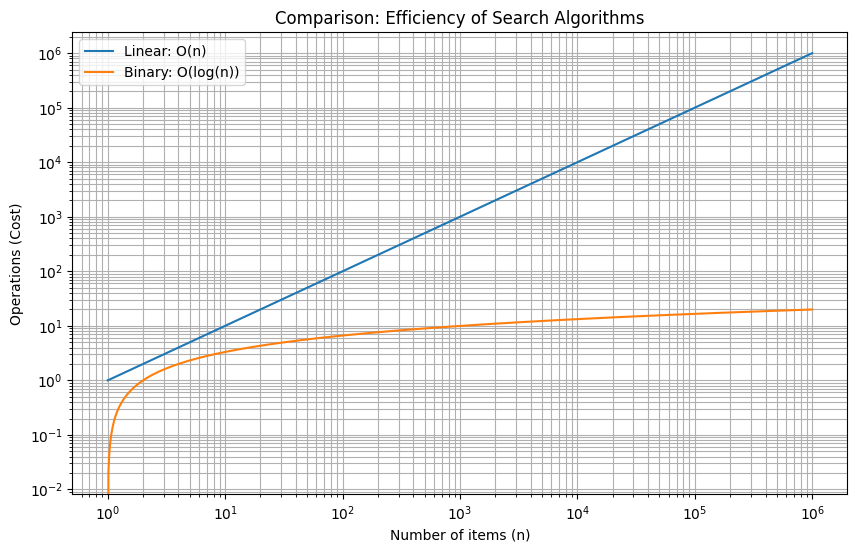

In [ ]:
# Run this cell

import numpy as np
import matplotlib.pyplot as plt

x = np.logspace(0, 6, 1000)
plt.figure(figsize=(10, 6))
plt.loglog(x, x, label='Linear: O(n)')
plt.loglog(x, np.log2(x), label='Binary: O(log(n))')
plt.xlabel('Number of items (n)')
plt.ylabel('Operations (Cost)')
plt.title('Comparison: Efficiency of Search Algorithms')
plt.legend()
plt.grid(True, which='both')
plt.show()

## Searching for Strings

What if you have a sorted list of strings and you have to use binary search to find the index of a particular string?  

Let's use `binary_search` on the following list!


In [9]:
fruits = ['Apples', 'Apricot', 'Bananas', 'Blackberries', 'Blueberries', 'Cantaloupe', 'Cherries']

# Write some code here:
print(binary_search(fruits, 'Bananas'))

2


This works because comparison operators (`<`,`>`,etc) work on strings!

When we do `'Apples' < 'Apricot'`, Python will compare the strings letter by letter:
1. Both words start with `'A'` so compare the second letter.
2. The second letter of both words is `'p'` so compare the third letter.
3. Now Python has to figure out which letter, `'p'` or `'r'`, is "smaller". Since p comes before r in the alphabet, p is considered "smaller" r.
4. Thus, `'Apples' < 'Apricot'` evaluates to `True`